# Part 1 · Foundations

**Qubits · quantum states · measurement · expectation values · entanglement.**

Why does anyone build quantum computers? Because some jobs are brutally expensive for classical machines, like simulating molecules and materials (the path to new drugs and better batteries) and searching enormous combinatorial spaces (scheduling, routing, portfolio selection), and some jobs are outright impossible for them, like producing randomness that is provably random, or communicating so that any eavesdropper reveals herself. This notebook is where all of that starts. By the end you will have built the quantum state behind a true random number generator, computed why wiretapping a qubit leaves detectable fingerprints, and seen for yourself the reason quantum computers are believed to be powerful: the $2^n$ memory wall.

We treat quantum states as **math objects** you can construct and probe directly, with no circuits and no simulator yet (those arrive in Part 2). By the end you will be able to:

- describe a qubit's state as a vector of complex **amplitudes**;
- predict **measurement** outcomes from a state via the **Born rule**, and compute **expectation values** of observables;
- create and quantify **superposition** and **entanglement**.

No prior quantum-computing knowledge is assumed: only Python and a little linear algebra (vectors, matrices, complex numbers).

### How QiliSDK is organized

Keep this three-layer map in mind; every part of the tutorial lives somewhere on it:

1. **Primitives**, the building blocks: `QTensor` (states and operators), `Gate`/`Circuit` (digital), `Hamiltonian`/`Schedule` (analog), and `Readout` (what to measure).
2. **Workflows**: *functionals* that bundle a primitive into something runnable (`DigitalPropagation`, `AnalogEvolution`, `VariationalProgram`).
3. **Execution**: *backends* that actually run a workflow: CPU (`QiliSim`), GPU (`CudaBackend`), or a real QPU, a quantum processing unit (`SpeQtrum`).

We start at the very bottom of the Primitives layer: **`QTensor`**, the quantum state itself.

In [1]:
# ▶ Run me first. No-op if QiliSDK is already installed; installs it on a fresh env (e.g. Google Colab).
try:
    import qilisdk
except ImportError:
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "qilisdk[openqasm,qir]==0.2.1", "matplotlib", "numpy"], check=True)
    import qilisdk  # Colab: if this still fails, Runtime > Restart session, then rerun
print("QiliSDK", qilisdk.__version__)

QiliSDK 0.2.1


In [2]:
%matplotlib inline
import numpy as np

from qilisdk.core import QTensor, ket, bra, ghz, tensor_prod, expect_val

## 1.1 · Qubits and quantum states

A **classical bit** is either $0$ or $1$. A **qubit** state is, concretely, something you already know how to store: a length-2 numpy array of complex numbers, `np.array([alpha, beta], dtype=complex)`, normalized so that `np.sum(np.abs(v)**2) == 1`. That is the entire data structure. A **ket** is that same array shaped as a column vector, shape `(2, 1)`; a **bra** is its conjugate transpose, `ket.conj().T`, a row vector of shape `(1, 2)`. Two quick glosses before they appear everywhere: the *complex conjugate* of $a+bi$ is $a-bi$ (flip the sign of the imaginary part), and the *dagger* symbol $\dagger$ means conjugate transpose, `.conj().T` in numpy.

Physicists write all this in *Dirac notation* (also called bra-ket notation), which is just typed syntax around those column and row vectors:

$$|\psi\rangle = \alpha\,|0\rangle + \beta\,|1\rangle,\qquad \alpha,\beta\in\mathbb{C},\qquad |\alpha|^2 + |\beta|^2 = 1.$$

Here $|\psi\rangle$ (read "ket psi") is the state, and $|0\rangle$ and $|1\rangle$ are the two *basis states*, represented as column vectors

$$|0\rangle = \begin{pmatrix}1\\0\end{pmatrix},\qquad |1\rangle = \begin{pmatrix}0\\1\end{pmatrix}.$$

The complex numbers $\alpha,\beta$ are called **amplitudes**. They are *not* probabilities, but the **Born rule** (made concrete in §1.2) turns them into probabilities. The constraint $|\alpha|^2+|\beta|^2=1$ is just the statement that those probabilities sum to one.

In QiliSDK, states and operators are both represented by a single object: the **`QTensor`** (quantum tensor). It is the `Core` primitive everything else is built on, and you can explore it with no simulator at all. `ket(0)` gives $|0\rangle$, `ket(1)` gives $|1\rangle$, and `bra(0)` gives the bra $\langle 0| = |0\rangle^\dagger$ (that conjugate-transpose row vector).

In [3]:
psi = ket(0)                                 # the |0> state
print("state vector:", psi.dense().ravel())  # amplitudes [1, 0]
print("nqubits:", psi.nqubits, " is_ket:", psi.is_ket())

state vector: [1.+0.j 0.+0.j]
nqubits: 1  is_ket: True


### Combining qubits: the tensor product

Two qubits do **not** live in two separate 2-D spaces glued together: they live in their *tensor product* (written $\otimes$), a single $2\times 2 = 4$-dimensional space with basis $|00\rangle, |01\rangle, |10\rangle, |11\rangle$. Every additional qubit *doubles* the vector, so $n$ qubits need $2^n$ complex amplitudes. Hold that thought; we quantify it in a moment.

QiliSDK uses **big-endian** ordering: in `ket(a, b)` the *first* argument is the most-significant qubit. So `ket(0, 1)` is $|01\rangle$, which is basis index $1$:

In [4]:
q = ket(0, 1)                      # the 2-qubit state |01>
print("dimension:", q.shape, "(= 2**2 x 1)")
print("|01> is basis index:", np.argmax(np.abs(q.dense())))   # 1  (big-endian)
print("a bra is the conjugate-transpose:", bra(0).dense())    # row vector [1, 0]

dimension: (4, 1) (= 2**2 x 1)
|01> is basis index: 1
a bra is the conjugate-transpose: [[1.+0.j 0.+0.j]]


### The $2^n$ memory wall: why quantum computers should exist

In 1982 Richard Feynman made the founding argument of this field. Simulating a quantum system on a classical computer means storing all $2^n$ amplitudes, and that memory bill grows exponentially, yet nature "runs" this computation effortlessly inside every molecule. His proposal: to simulate nature, build hardware that natively *is* quantum, hardware whose physical state holds those $2^n$ amplitudes for you. It is, at its core, a memory-complexity argument. Watch the wall arrive (each amplitude is a `complex128`, 16 bytes):

In [5]:
print("Storing one quantum state in classical RAM (complex128 = 16 bytes per amplitude):")
for n in [1, 2, 4, 8, 12, 20]:
    amps = ket(*([0] * n)).dense()   # ket(0, 0, ..., 0) = the n-qubit |00...0> state
    print(f"  {n:>2} qubits -> {amps.size:>9,} amplitudes = {amps.nbytes:>12,} bytes")

print("Extrapolating with plain Python (16 * 2**n bytes):")
print(f"  33 qubits -> {16 * 2**33 / 1e9:,.0f} GB   (a very large workstation)")
print(f"  50 qubits -> {16 * 2**50 / 1e15:,.0f} PB  (about twice the memory of the Frontier supercomputer)")
print(f"  280 qubits -> {16 * 2**280:.1e} bytes (more than the ~1e80 atoms in the observable universe)")

Storing one quantum state in classical RAM (complex128 = 16 bytes per amplitude):
   1 qubits ->         2 amplitudes =           32 bytes
   2 qubits ->         4 amplitudes =           64 bytes
   4 qubits ->        16 amplitudes =          256 bytes
   8 qubits ->       256 amplitudes =        4,096 bytes
  12 qubits ->     4,096 amplitudes =       65,536 bytes
  20 qubits -> 1,048,576 amplitudes =   16,777,216 bytes
Extrapolating with plain Python (16 * 2**n bytes):
  33 qubits -> 137 GB   (a very large workstation)
  50 qubits -> 18 PB  (about twice the memory of the Frontier supercomputer)
  280 qubits -> 3.1e+85 bytes (more than the ~1e80 atoms in the observable universe)


### The catch: you cannot read the amplitudes out

The memory wall can start to sound like a free lunch. It isn't: when you *measure* $n$ qubits (§1.2), you get back exactly $n$ classical bits, one $0/1$ per qubit, and the $2^n$-amplitude state is destroyed in the process. The exponential state is physically real, but it is not addressable memory. Every useful quantum algorithm must therefore choreograph **interference** so that the amplitudes of wrong answers cancel and the amplitudes of right answers reinforce, leaving the few bits you *do* read out worth reading. Parts 3 and 4 of this tutorial show two different ways to pull that off.

### Superposition

The defining quantum feature is **superposition**: a qubit can be in a combination of $|0\rangle$ *and* $|1\rangle$ at once. The most important examples are the *plus* and *minus* states, both equal superpositions:

$$|+\rangle = \tfrac{1}{\sqrt{2}}\big(|0\rangle + |1\rangle\big),\qquad |-\rangle = \tfrac{1}{\sqrt{2}}\big(|0\rangle - |1\rangle\big).$$

Both have amplitudes of magnitude $1/\sqrt 2$, so both give outcomes $0$ and $1$ with probability $\tfrac12$ when measured in the **computational basis** (the standard $|0\rangle/|1\rangle$ basis; it is also called the $Z$ basis, after the observable you will meet in §1.3). Yet they are **different states**: the *sign* (more generally, the complex *phase*) of an amplitude is physical. That relative phase is what enables **interference**. (An overall *global* phase, e.g. multiplying the whole vector by $-1$, is **not** observable.)

The code below builds $|+\rangle$ three equivalent ways, then shows interference in its purest form: applying the Hadamard operator $H$ twice returns *exactly* $|0\rangle$, because the two paths to $|1\rangle$ carry opposite signs and cancel. Contrast a classical coin: flip it twice and the randomness compounds. Flip a qubit with $H$ twice and the randomness *un-happens*. When you read nested `@` expressions, read them inside out like `f(g(x))`: the innermost operator acts first.

> ⚠️ **Use `@` (matrix multiplication), not `*`, to apply an operator to a state.** In `QTensor`, `*` is element-wise/scalar multiplication and will silently give you the wrong vector.

In [6]:
plus = QTensor.uniform(1)                       # built-in equal superposition
print("uniform  :", np.round(plus.dense().ravel(), 3))           # [0.707 0.707]

H = QTensor(np.array([[1, 1], [1, -1]]) / np.sqrt(2))            # the Hadamard operator (a gate; see Part 2)
print("H @ |0>  :", np.round((H @ ket(0)).dense().ravel(), 3))   # [0.707 0.707]  (@, not *)
print("|0> + |1>:", np.round((ket(0) + ket(1)).normalized().dense().ravel(), 3))

# Interference: apply H twice and the two paths to |1> cancel EXACTLY.
print("H @ H @ |0>:", np.round((H @ (H @ ket(0))).dense().ravel(), 3))   # back to [1, 0]

uniform  : [0.707+0.j 0.707+0.j]
H @ |0>  : [0.707+0.j 0.707+0.j]
|0> + |1>: [0.707+0.j 0.707+0.j]
H @ H @ |0>: [1.+0.j 0.+0.j]


### Visualizing a qubit: the Bloch sphere

Any single-qubit *pure* state can be written, up to global phase, as

$$|\psi\rangle = \cos\tfrac{\theta}{2}\,|0\rangle + e^{i\varphi}\sin\tfrac{\theta}{2}\,|1\rangle,$$

so it maps to a point on a unit sphere, the **Bloch sphere**, with polar angle $\theta$ and azimuth $\varphi$. Matching this to our amplitudes: $\alpha = \cos(\theta/2)$ and $\beta = e^{i\varphi}\sin(\theta/2)$. The factor $e^{i\varphi}$ is the phase knob: a point on the unit circle in the complex plane (Euler's formula, $e^{i\varphi} = \cos\varphi + i\sin\varphi$). The half-angle $\theta/2$ is a convention that makes the geometry work out; do not spend energy internalizing it today. $|0\rangle$ sits at the north pole, $|1\rangle$ at the south pole, and $|+\rangle$/$|-\rangle$ on the equator (the $\pm X$ axis). `QTensor.draw()` renders it:

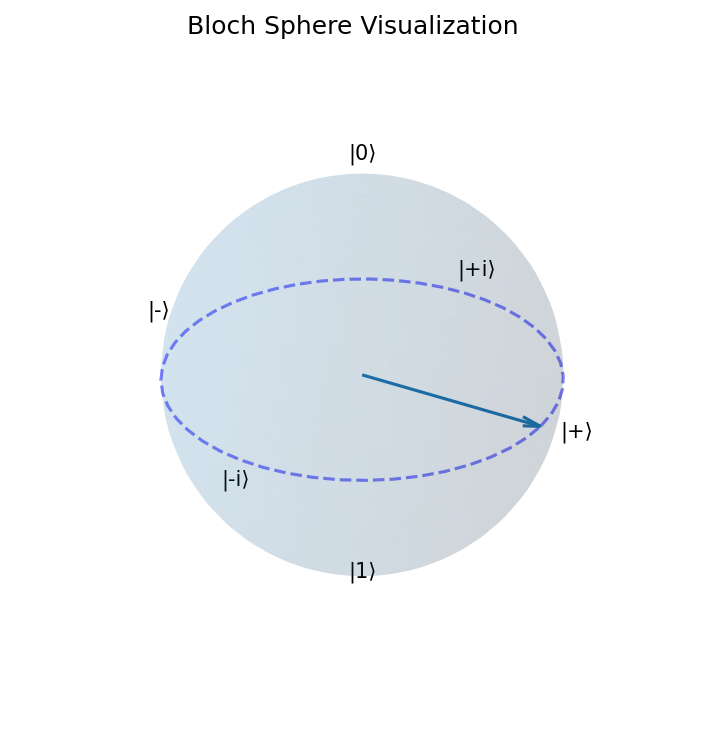

In [7]:
QTensor.uniform(1).draw()   # |+> points along the +X axis of the Bloch sphere

## 1.2 · Measurement and the Born rule

A qubit holds continuous amplitudes, but when you **measure** it in the computational basis you get a single classical bit, $0$ or $1$. The **Born rule** says the probabilities are the squared magnitudes of the amplitudes:

$$P(0) = |\alpha|^2,\qquad P(1) = |\beta|^2.$$

Measurement is also **destructive**: it *collapses* the superposition onto the basis state you observed, so measuring the same (now-collapsed) qubit again just returns the same value. To gather statistics you must **prepare the state afresh and measure again**; that is exactly what the `nshots` of a real device do (you will see this in Part 2).

This destructive coin flip is already a shipping product. Measuring $|+\rangle$ over and over is a **provably fair coin**: the 50/50 odds come from physics, not from an algorithm that could be predicted or reverse-engineered. Commercial quantum random number generators (QRNGs) work exactly this way: ID Quantique ships QRNG chips inside consumer phones, and the ANU QRNG serves quantum random bytes over a public web API. Contrast Python's `random` module, a deterministic pseudo-random generator whose own documentation forbids using it for security purposes.

`QTensor.probabilities()` returns the Born-rule distribution directly. One caveat about the sampling line below: Part 1 has no simulator yet, so we sample *classically* from the quantum probabilities with `np.random.choice`. Real measurement happens in Part 2.

In [8]:
plus = QTensor.uniform(1)
print("fair coin   P(0), P(1):", [round(p, 4) for p in plus.probabilities()])    # [0.5, 0.5]

theta = np.pi / 6
biased = np.cos(theta) * ket(0) + np.sin(theta) * ket(1)   # scalar * is fine for scaling
print("biased coin P(0), P(1):", [round(p, 4) for p in biased.probabilities()])  # [0.75, 0.25]

# No simulator yet: mimic 10 fresh prepare-and-measure rounds by sampling classically.
draws = np.random.choice([0, 1], size=10, p=plus.probabilities())
print("10 simulated measurements of |+>:", draws)

fair coin   P(0), P(1): [0.5, 0.5]
biased coin P(0), P(1): [0.75, 0.25]
10 simulated measurements of |+>: [0 0 1 0 0 0 1 1 0 0]


### 🧩 Exercise 1.1: build a loaded quantum coin

Casinos load dice by shaving edges. You are going to load a coin at the *amplitude* level: build a single-qubit state that outputs $1$ with probability **exactly 0.75**, odds guaranteed by physics rather than by code someone could tamper with.

Use the one-parameter family $|\psi(\theta)\rangle = \cos\theta\,|0\rangle + \sin\theta\,|1\rangle$, which by the Born rule gives $P(1) = \sin^2\theta$.

1. Choose `theta` so that $\sin^2\theta = 0.75$ (solve on paper, or let numpy invert it for you).
2. Build the state yourself from `ket(0)` and `ket(1)`, scaled by the right amplitudes.
3. Verify with `probabilities()` that it reads `[0.25, 0.75]`.
4. Draw 20 bits with `np.random.choice`.

*Payoff: you just engineered a probability distribution at the amplitude level, the Born rule run in reverse. That is what real QRNG hardware bakes into silicon.*

In [9]:
theta = np.arcsin(np.sqrt(0.75))          # = pi/3, since sin(pi/3)**2 = 3/4
loaded = np.cos(theta) * ket(0) + np.sin(theta) * ket(1)

print("theta:", round(theta, 4), "(= pi/3 =", round(np.pi / 3, 4), ")")
print("P(0), P(1):", [round(p, 4) for p in loaded.probabilities()])   # [0.25, 0.75]

bits = np.random.choice([0, 1], size=20, p=loaded.probabilities())
print("20 loaded-coin bits:", bits)
print("fraction of 1s:", bits.mean(), "(expect about 0.75)")

theta: 1.0472 (= pi/3 = 1.0472 )
P(0), P(1): [0.25, 0.75]
20 loaded-coin bits: [1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1]
fraction of 1s: 0.85 (expect about 0.75)


## 1.2b · Why you cannot wiretap a qubit

Copying a byte off a network is undetectable: `tcpdump` leaves no marks on the packets it captures. Measuring a qubit is different. Measurement collapses the state, and a measurement in the *wrong basis* leaves fingerprints. That asymmetry is a security primitive, and you can compute it with nothing but `QTensor`.

The setup: Alice encodes each bit in one of two bases, chosen at random per bit: the standard basis ($|0\rangle/|1\rangle$) or the X basis ($|+\rangle/|-\rangle$). "Measuring in the X basis" simply means applying $H$ first and then reading $0/1$ as usual; since $H$ maps $|+\rangle \to |0\rangle$ and $|-\rangle \to |1\rangle$, it is a change of basis (and our first live use of the `@`-not-`*` rule). When Bob measures in the same basis Alice used, he reads her bit perfectly.

Now insert Eve, who intercepts each qubit, measures it, and re-sends what she saw. Half the time she guesses the wrong basis, collapses the state, and forwards damaged goods: on those qubits Bob's bit flips with probability $\tfrac12$. Net effect, computed below: this intercept-and-resend attack imprints an inescapable **25% error rate** on the bits where Alice's and Bob's bases matched. Alice and Bob sacrifice a few of those bits, compare them over a public channel, and an error rate near 25% exposes Eve.

This is the core idea of **BB84 quantum key distribution**, and it is deployed technology: banks run QKD links, and the Micius satellite distributed keys over 1200 km. To be precise: 25% is the signature of *this* attack; full BB84 security analyses cover subtler attacks too.

In [10]:
H_op = QTensor(np.array([[1, 1], [1, -1]]) / np.sqrt(2))

# Alice encodes bit 0 in the X basis: she sends |+> = H|0>.
plus = H_op @ ket(0)

# No eavesdropper: Bob measures in the same basis (apply H, then read 0/1).
p_bob = (H_op @ plus).probabilities()
print("no Eve, Bob reads:", [round(p, 4) for p in p_bob])                        # [1.0, 0.0] -> always bit 0

# Eve measured in the WRONG (standard) basis, collapsing |+> to |0> or |1>, 50/50.
# Bob then measures her re-sent qubit in the X basis:
p_err_if_wrong = 0.5 * (H_op @ ket(0)).probabilities()[1] + 0.5 * (H_op @ ket(1)).probabilities()[1]
print("error rate when Eve picked the wrong basis:", round(p_err_if_wrong, 4))   # 0.5

# Eve guesses the right basis half the time (no damage) and the wrong basis half the time:
qber = 0.5 * 0.0 + 0.5 * p_err_if_wrong
print("overall error rate Eve causes:", round(qber, 4))                          # 0.25

no Eve, Bob reads: [1.0, 0.0]
error rate when Eve picked the wrong basis: 0.5
overall error rate Eve causes: 0.25


## 1.3 · Expectation values

Often we do not want a full histogram, just an **average**. An **observable** is a *Hermitian* operator $O$; Hermitian means $O$ equals its own conjugate transpose (`O == O.conj().T` in numpy), which guarantees the averages it produces are real numbers. The **eigenvalues** of $O$ are the possible measurement outcomes, and an **eigenstate** is a state whose outcome is certain: measure an eigenstate and you always get its eigenvalue. The **expectation value**

$$\langle O\rangle = \langle\psi|\,O\,|\psi\rangle$$

looks cryptic but decodes as **bra @ operator @ ket**: a row vector times a matrix times a column vector, i.e. one number. It is the mean outcome you would get by averaging many measurements.

The most common observable is **Pauli-$Z$**, with eigenvalues $+1$ (eigenstate $|0\rangle$) and $-1$ (eigenstate $|1\rangle$). So $\langle Z\rangle = P(0)\cdot(+1) + P(1)\cdot(-1) = P(0) - P(1) \in [-1, 1]$ measures how "$0$-ish" versus "$1$-ish" a state is. **Pauli-$X$** does the same in the $|+\rangle/|-\rangle$ basis.

Hold on to this idea; it powers the rest of the day. The average energy of a molecule is exactly such an expectation value, and Part 4 finds the state that minimizes one. This single number is what every algorithm in Parts 3 and 4 minimizes.

Use `expect_val(operator, state)`; note the **operator comes first**. The code also spells the sandwich out by hand so you can see there is no magic:

In [11]:
Z_op = QTensor(np.array([[1, 0], [0, -1]]))     # Pauli-Z observable

for name, state in [("|0>", ket(0)), ("|1>", ket(1)), ("|+>", QTensor.uniform(1))]:
    print(f"<Z> on {name}: {round(expect_val(Z_op, state).real, 4)}")   # +1, -1, 0

# The sandwich <psi|Z|psi> written out: bra @ operator @ ket = a 1x1 matrix.
state = QTensor.uniform(1)
sandwich = state.adjoint() @ Z_op @ state       # .adjoint() = dagger = conjugate transpose
print("by hand    :", round(sandwich.dense()[0, 0].real, 4))
print("expect_val :", round(expect_val(Z_op, state).real, 4))

# And <Z> is exactly P(0) - P(1):
p = state.probabilities()
print("P(0) - P(1):", round(p[0] - p[1], 4))    # 0.0 for |+>

<Z> on |0>: 1.0
<Z> on |1>: -1.0
<Z> on |+>: 0.0
by hand    : 0.0
expect_val : 0.0
P(0) - P(1): 0.0


### 🧩 Exercise 1.2: probe the $|-\rangle$ state

$|+\rangle$ and $|-\rangle$ produce *identical* 50/50 statistics when measured in the computational basis, so in what sense are they different states at all? Prove they are: build $|-\rangle = \tfrac{1}{\sqrt2}(|0\rangle - |1\rangle)$ and verify that $\langle Z\rangle = 0$ (equal $0/1$ probabilities, just like $|+\rangle$) **but** $\langle X\rangle = -1$: the state $|-\rangle$ is the $-1$ eigenstate of $X$, while $|+\rangle$ has $\langle X\rangle = +1$, and that is what tells them apart.

Hints: subtract two kets and call `.normalized()` to build the state; `expect_val(operator, state)` returns a complex number, so take `.real` and round it.

*Closing thought: the phase information that $Z$ measurements cannot see is exactly what interference-based algorithms and quantum key distribution manipulate.*

In [12]:
Z_op = QTensor(np.array([[1, 0], [0, -1]]))
X_op = QTensor(np.array([[0, 1], [1, 0]]))

minus = (ket(0) - ket(1)).normalized()
print("|-> amplitudes:", np.round(minus.dense().ravel(), 3))
print("P(0), P(1)    :", [round(p, 4) for p in minus.probabilities()])   # [0.5, 0.5], same as |+>
print("<Z> on |->    :", round(expect_val(Z_op, minus).real, 4))         # 0.0
print("<X> on |->    :", round(expect_val(X_op, minus).real, 4))         # -1.0

|-> amplitudes: [ 0.707+0.j -0.707+0.j]
P(0), P(1)    : [0.5, 0.5]
<Z> on |->    : 0.0
<X> on |->    : -1.0


## 1.4 · Entanglement

Some multi-qubit states **cannot be written as a product** of single-qubit states: these are *entangled*. The canonical example is the **Bell state**

$$|\Phi^+\rangle = \tfrac{1}{\sqrt 2}\big(|00\rangle + |11\rangle\big).$$

No pair of single-qubit states $|a\rangle, |b\rangle$ satisfies $|\Phi^+\rangle = |a\rangle\otimes|b\rangle$; try to factor it and you will fail. Watch what that means operationally. Measure the Bell state and only `00` and `11` ever come out: two parties holding one qubit each receive a **random bit they always agree on**. Compare the unentangled state $|+\rangle\otimes|+\rangle$: all four outcomes appear at 25%, so the two parties agree only half the time, no better than independent coin flips.

Why that matters: entanglement manufactures **correlated randomness that exists only between its holders**: nobody chose the bit, it did not exist before the measurements, and (as the next demo computes) an outsider examining one qubit alone sees pure noise. Perfectly correlated for insiders, featureless for outsiders: that combination is precisely what a cryptographic key is. This resource powers entanglement-based quantum key distribution, and the Bell-test experiments that confirmed it earned the 2022 Nobel Prize in Physics. One caveat: measuring your half tells you what the other side *will* read, but it transmits no information by itself, so entanglement gives no faster-than-light signaling.

In [13]:
bell = ghz(2)                                 # for 2 qubits, ghz() builds the Bell state
print("Bell amplitudes     :", np.round(bell.dense().ravel(), 3))              # [0.707 0 0 0.707]
print("Bell P(00,01,10,11) :", [round(p, 4) for p in bell.probabilities()])    # [0.5, 0.0, 0.0, 0.5]

plus = QTensor.uniform(1)
prod = tensor_prod([plus, plus])              # unentangled: each qubit is its own |+>
print("|+>|+> P(00..11)    :", [round(p, 4) for p in prod.probabilities()])    # [0.25, 0.25, 0.25, 0.25]

# The same trick scales: a 3-qubit GHZ state gives three parties one shared random bit.
print("GHZ(3) P(000..111)  :", [round(p, 4) for p in ghz(3).probabilities()])  # only 000 and 111

Bell amplitudes     : [0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]
Bell P(00,01,10,11) : [0.5, 0.0, 0.0, 0.5]
|+>|+> P(00..11)    : [0.25, 0.25, 0.25, 0.25]
GHZ(3) P(000..111)  : [0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5]


### One level deeper: the reduced state (for the curious)

The claim "an outsider sees pure noise" can be computed exactly, using two tools you will meet again in Part 5.

First, the **density matrix** $\rho = |\psi\rangle\langle\psi|$ (ket times bra, a matrix): a representation that can also express a probability-weighted *mixture* of states, like a dict mapping states to probabilities, where a ket can only express one definite vector. Part 5 gives it a full treatment; today it is just the input format for the second tool.

Second, the **partial trace** answers "what does qubit 0 look like on its own, ignoring its partner?" The convention to memorize: `partial_trace({0})` **keeps** qubit 0 and discards (traces out) all the others.

For the Bell state the reduced state of qubit 0 comes out $\rho_A = \tfrac12 I$: a 50/50 mixture of $|0\rangle$ and $|1\rangle$ with no phase information whatsoever, a perfectly fair coin. That is the outsider's view, computed. The **von Neumann entropy**

$$S(\rho) = -\sum_i \lambda_i \ln\lambda_i$$

(where $\lambda_i$ are the eigenvalues of $\rho$) quantifies the randomness. QiliSDK measures it in **nats** (natural logarithm), so maximal one-qubit randomness is $\ln 2 \approx 0.6931$ nats, i.e. one full bit. A product state scores exactly $0.0$: no entanglement, no shared randomness. And the pattern generalizes: in a 3-qubit GHZ state, keep any single qubit and trace out the others, and that one-qubit reduced state is again $\tfrac12 I$.

In [14]:
rho_A = bell.as_density_matrix().partial_trace({0})    # KEEPS qubit 0, traces out qubit 1
print("reduced state of qubit 0:\n", np.round(rho_A.dense(), 3))            # I/2 -> a fair coin
print("Bell entanglement entropy:", round(rho_A.entropy_von_neumann(), 4))  # 0.6931 = ln 2 (maximal)

prod00 = tensor_prod([ket(0), ket(0)])                 # |00> is a product (unentangled) state
print("product-state entropy    :",
      round(prod00.as_density_matrix().partial_trace({0}).entropy_von_neumann(), 4))   # 0.0

g3 = ghz(3)
print("GHZ(3) per-qubit entropies:",
      [round(g3.as_density_matrix().partial_trace({q}).entropy_von_neumann(), 4) for q in range(3)])

reduced state of qubit 0:
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
Bell entanglement entropy: 0.6931
product-state entropy    : 0.0
GHZ(3) per-qubit entropies: [0.6931, 0.6931, 0.6931]


## Recap and what's next

- A qubit state is a normalized complex vector of **amplitudes**; $n$ qubits need $2^n$ of them. That **memory wall** is Feynman's founding argument for quantum computers. The catch: measurement returns only $n$ classical bits, so algorithms must choreograph **interference** to make those bits worth reading.
- **Measurement** follows the **Born rule** ($P = |\text{amplitude}|^2$) and **collapses** the state. Engineered amplitudes give physics-guaranteed randomness: a real product (QRNG), and you built the loaded-coin version yourself.
- Measuring in the wrong basis leaves fingerprints: an intercept-and-resend eavesdropper imprints a 25% error rate, the core idea of **quantum key distribution**.
- The **expectation value** $\langle O\rangle = \langle\psi|O|\psi\rangle$ (bra @ operator @ ket) is the single number that annealing (Part 3) and variational algorithms (Part 4) minimize.
- **Entanglement** is correlated randomness only its holders share: perfectly correlated bits for insiders ($\ln 2$ nats of entropy per Bell qubit), pure noise ($\tfrac12 I$) for anyone outside.

**Part 2, Circuits / Digital Quantum Computing:** states now get *operated on* by **gates**, assembled into **circuits**, and **run** on the `QiliSim` simulator, including your first real program: a quantum dice roller.